In [103]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ahora importa el módulo
from RRAM.Representate import config_ax, setup_plt

setup_plt(plt, latex=True, scaling=2)

In [104]:
# Rutas de los archivos
ruta_raiz = Path.cwd()
ruta_datos = ruta_raiz / "Datos_Experimentales" / "Ciclos_Experimentales"

# Cargar datos experimentales
name_set_file = "Cycle_p_1000.txt"
ruta_completa = ruta_datos / name_set_file

# Verificar que el archivo existe
if ruta_completa.exists():
    print(f"Leyendo archivo: {ruta_completa}")
    # Usar np.loadtxt como en el código original
    data_set = np.loadtxt(ruta_completa)
else:
    print(f"El archivo {ruta_completa} no existe. Verificar la ruta.")

# Ahora crear el DataFrame a partir de estas columnas extraídas

df_set = pd.DataFrame({"Voltaje": data_set[:, 0], "Corriente": data_set[:, 1]})
df_set_filtrado = df_set.iloc[0:110] # Seleccionar solo las primeras 111 filas empezando desde la fila 0
 
# Extraer voltajes y corrientes
V_set = df_set_filtrado["Voltaje"].values
I_set = df_set_filtrado["Corriente"].values

# Mostrar las primeras filas para verificar
print("Primeras filas del DataFrame:")
print(df_set_filtrado.head())

# Información sobre el tamaño del DataFrame
num_filas, num_columnas = df_set_filtrado.shape
print(f"El DataFrame tiene {num_filas} filas y {num_columnas} columnas")

# Encontrar la derivada numérica de la corriente con respecto al voltaje
dI_dV = np.gradient(df_set_filtrado['Corriente'], df_set_filtrado['Voltaje'])

# Ordeno el vector de dI_dV de mayor a menor
dI_dV_sorted = np.sort(dI_dV)[::-1]

num_valores_maximos = 5

# Extraigo los 3 valores más grandes con su voltaje correspondiente
top_indices = np.argsort(dI_dV)[-num_valores_maximos:]

print(np.argsort(dI_dV)[-num_valores_maximos:])

top_derivadas = dI_dV_sorted[:num_valores_maximos]
top_voltajes = df_set_filtrado['Voltaje'].values[top_indices]

# Encontrar el índice del máximo valor de la derivada
indice_max_derivada = np.argmax(dI_dV)

# Obtener el voltaje correspondiente al máximo de la derivada
V_set_max_derivada = V_set[indice_max_derivada]

print(f"El valor de V_set obtenido es: {V_set_max_derivada} V")

Leyendo archivo: c:\Users\jimdo\Documents\GitHub\RRAM_Simulation\Datos_Experimentales\Ciclos_Experimentales\Cycle_p_1000.txt
Primeras filas del DataFrame:
   Voltaje  Corriente
0     0.01   0.000019
1     0.02   0.000037
2     0.03   0.000055
3     0.04   0.000074
4     0.05   0.000093
El DataFrame tiene 110 filas y 2 columnas
[58 75 76 54 55]
El valor de V_set obtenido es: 0.56 V


C:\Users\jimdo\AppData\Local\Temp\ipykernel_39392\2681461154.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(V_set, I_set, 'b-', linewidth=2, color='blue')
C:\Users\jimdo\AppData\Local\Temp\ipykernel_39392\2681461154.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "go" (-> color='g'). The keyword argument will take precedence.
  ax1.plot(V_set[idx], I_set[idx], 'go', markersize=6, color='red')
C:\Users\jimdo\AppData\Local\Temp\ipykernel_39392\2681461154.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  ax2.plot(V_set, dI_dV, 'g-', linewidth=2, color = 'blue')
C:\Users\jimdo\AppData\Local\Temp\ipykernel_39392\2681461154.py:39: UserWarning: color is redundantly defined by the 'color' keyword argumen

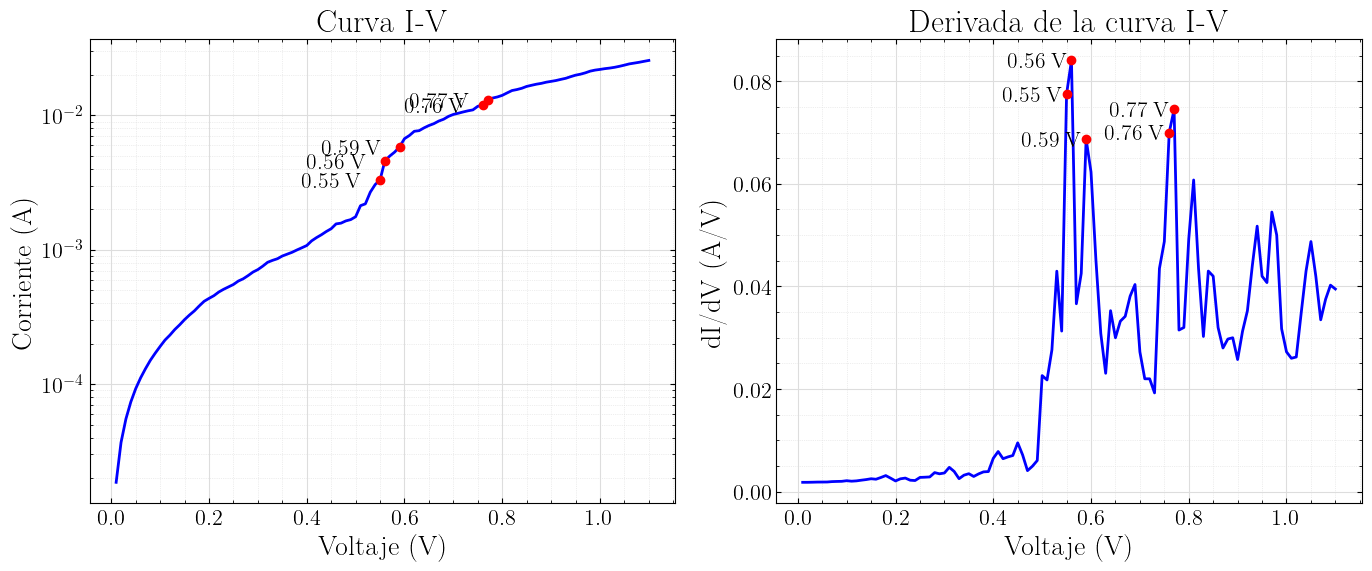

In [105]:
# Crear una figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

config_ax(ax1)
config_ax(ax2)

# En el primer subplot, graficar la curva I-V
ax1.plot(V_set, I_set, 'b-', linewidth=2, color='blue')
ax1.set_xlabel('Voltaje (V)')
ax1.set_ylabel('Corriente (A)')
ax1.set_title('Curva I-V')
ax1.set_yscale('log')
ax1.grid(True)

# Solo marcar los 3 puntos con mayor derivada en el primer subplot
for i, idx in enumerate(top_indices):
    ax1.plot(V_set[idx], I_set[idx], 'go', markersize=6, color='red')
    ax1.annotate(
        f"{V_set[idx]:.2f} V",
        (V_set[idx], I_set[idx]),
        
        textcoords="offset points",
        xytext=(-35, -5),
        ha="center",
        fontsize=16,
        fontweight='bold'
    )


# En el segundo subplot, graficar la derivada de la corriente respecto al voltaje
ax2.plot(V_set, dI_dV, 'g-', linewidth=2, color = 'blue')
ax2.set_xlabel('Voltaje (V)')
ax2.set_ylabel('dI/dV (A/V)')
ax2.set_title('Derivada de la curva I-V')
ax2.grid(True)

# Solo marcar los 3 puntos con mayor derivada en el segundo subplot
for i, idx in enumerate(top_indices):
    ax2.plot(V_set[idx], dI_dV[idx], 'go', markersize=6, color='red')
    ax2.annotate(f'{V_set[idx]:.2f} V', 
                (V_set[idx], dI_dV[idx]),
                textcoords="offset points", 
                xytext=(-25, -5),
                ha='center',
                fontsize=16,
                fontweight='bold')

plt.tight_layout()
plt.show()
